# 690 Retrieval Optimization

690개 문서 기반 Chroma DB에서 retrieval 성능을 다시 튜닝한 기록입니다.

기준 실험은 80번이고, 125개 DB에서 효과가 있었던 query decomposition, RRF, document-level selection 계열을 690 DB에 다시 적용했습니다.

최초 최적화에서는 91번이 가장 좋았고, 이후 target-aware 보수형 보강을 적용한 95번이 소폭 더 좋았습니다.

- vector store: Chroma
- embedding model: `nlpai-lab/KURE-v1`
- retriever: dense
- query decomposition: conditional + RRF
- per-query candidates: 75
- final selection: document scoring, `mean_top_n`, top 3 chunks 평균
- target-aware 보강: 기존 top-3 문서는 유지하고 남은 슬롯에 target별 후보 보강
- document score candidates: 300


## 1. 결과 로그 불러오기

`eval/evaluation/outputs/eval/experiment_logs/phase1_retrieval_experiments.csv`에 누적된 평가 로그에서 690 실험만 가져옵니다.

In [55]:
from pathlib import Path
import csv
import json
import pandas as pd

LOG_PATH = Path('../eval/evaluation/outputs/eval/experiment_logs/phase1_retrieval_experiments.csv')

EXPERIMENT_LABELS = {
    '80_dense_qdecomp_rrf_diverse250_kure_chroma_690_canonical': '80 baseline: per50 + diverse250',
    '81_dense_qdecomp_rrf_diverse250_keyword_rerank_kure_chroma_690_canonical': '81 keyword rerank',
    '82_dense_qdecomp_rrf_per50_diverse200_kure_chroma_690_canonical': '82 per50 + diverse200',
    '83_dense_qdecomp_rrf_per50_diverse300_kure_chroma_690_canonical': '83 per50 + diverse300',
    '84_dense_qdecomp_rrf_per50_diverse400_kure_chroma_690_canonical': '84 per50 + diverse400',
    '85_dense_qdecomp_rrf_per50_diverse250_source_file_kure_chroma_690_canonical': '85 source_file diversity',
    '86_dense_qdecomp_rrf_per75_diverse250_kure_chroma_690_canonical': '86 per75 + diverse250',
    '87_dense_qdecomp_rrf_per75_diverse300_kure_chroma_690_canonical': '87 per75 + diverse300',
    '88_dense_qdecomp_rrf_per75_diverse400_kure_chroma_690_canonical': '88 per75 + diverse400',
    '89_dense_qdecomp_rrf_per100_diverse300_kure_chroma_690_canonical': '89 per100 + diverse300',
    '90_dense_qdecomp_rrf_per100_diverse400_kure_chroma_690_canonical': '90 per100 + diverse400',
    '91_dense_qdecomp_rrf_per75_docscore_mean3_300_kure_chroma_690_canonical': '91 docscore mean3, candidates300',
    '92_dense_qdecomp_rrf_per75_docscore_max_300_kure_chroma_690_canonical': '92 docscore max, candidates300',
    '93_dense_qdecomp_rrf_per75_docscore_sum3_300_kure_chroma_690_canonical': '93 docscore sum3, candidates300',
    '94_dense_qdecomp_rrf_per75_docscore_mean3_targetaware30_max3_kure_chroma_690_canonical': '94 target-aware aggressive',
    '95_dense_qdecomp_rrf_per75_docscore_mean3_targetaware30_preserve3_kure_chroma_690_canonical': '95 target-aware preserve top3',
}

def load_latest_experiments(log_path: Path) -> pd.DataFrame:
    latest = {}
    with log_path.open(encoding='utf-8-sig') as file:
        for row in csv.DictReader(file):
            name = row['experiment_name']
            if name not in EXPERIMENT_LABELS:
                continue
            by_type = json.loads(row.get('by_type_summary_json') or '[]')
            by_diff = json.loads(row.get('by_difficulty_summary_json') or '[]')
            type_b = next((item for item in by_type if item.get('type') == 'B'), {})
            type_e = next((item for item in by_type if item.get('type') == 'E'), {})
            hard = next((item for item in by_diff if item.get('difficulty') == '상'), {})
            latest[name] = {
                'experiment_name': name,
                'setting': EXPERIMENT_LABELS[name],
                'hit_at_5': float(row['overall_hit_at_5']),
                'mrr_at_5': float(row['overall_mrr_at_5']),
                'ndcg_at_5': float(row['overall_ndcg_at_5']),
                'type_b_ndcg': type_b.get('ndcg_at_5'),
                'type_b_doc_recall': type_b.get('doc_recall_at_5'),
                'type_b_multi_doc_recall': type_b.get('multi_doc_recall_at_5'),
                'type_e_ndcg': type_e.get('ndcg_at_5'),
                'type_e_doc_recall': type_e.get('doc_recall_at_5'),
                'hard_ndcg': hard.get('ndcg_at_5'),
                'run_datetime': row.get('run_datetime'),
                'predictions_path': row.get('predictions_path'),
            }
    return pd.DataFrame(latest.values()).sort_values('ndcg_at_5', ascending=False).reset_index(drop=True)

summary = load_latest_experiments(LOG_PATH)
summary


,experiment_name,setting,hit_at_5,mrr_at_5,ndcg_at_5,type_b_ndcg,type_b_doc_recall,type_b_multi_doc_recall,type_e_ndcg,type_e_doc_recall,hard_ndcg,run_datetime,predictions_path
0,95_dense_qdecomp_rrf_per75_docscore_mean3_targetaware30_preserve3_kure_chroma_690_canonical,95 target-aware preserve top3,1.000,0.947733,0.911912,0.839462,0.854583,0.854583,0.928895,0.97,0.877804,2026-05-27T02:55:35,/home/beomsoo/chatbot/outputs/predictions/95_dense_qdecomp_rrf_per75_docscore_mean3_targetaware30_preserve3_kure_chroma_690_canonical.jsonl
1,91_dense_qdecomp_rrf_per75_docscore_mean3_300_kure_chroma_690_canonical,"91 docscore mean3, candidates300",0.998,0.947333,0.911264,0.837844,0.851250,0.851250,0.928895,0.97,0.873362,2026-05-26T09:49:52,/home/beomsoo/chatbot/outputs/predictions/91_dense_qdecomp_rrf_per75_docscore_mean3_300_kure_chroma_690_canonical.jsonl
2,93_dense_qdecomp_rrf_per75_docscore_sum3_300_kure_chroma_690_canonical,"93 docscore sum3, candidates300",0.998,0.947333,0.911259,0.837831,0.850417,0.850417,0.928895,0.97,0.875940,2026-05-26T09:55:54,/home/beomsoo/chatbot/outputs/predictions/93_dense_qdecomp_rrf_per75_docscore_sum3_300_kure_chroma_690_canonical.jsonl
3,87_dense_qdecomp_rrf_per75_diverse300_kure_chroma_690_canonical,87 per75 + diverse300,0.998,0.939133,0.907934,0.832183,0.855417,0.855417,0.902718,0.97,0.869816,2026-05-26T09:36:57,/home/beomsoo/chatbot/outputs/predictions/87_dense_qdecomp_rrf_per75_diverse300_kure_chroma_690_canonical.jsonl
4,88_dense_qdecomp_rrf_per75_diverse400_kure_chroma_690_canonical,88 per75 + diverse400,0.998,0.939133,0.907934,0.832183,0.855417,0.855417,0.902718,0.97,0.869816,2026-05-26T09:40:00,/home/beomsoo/chatbot/outputs/predictions/88_dense_qdecomp_rrf_per75_diverse400_kure_chroma_690_canonical.jsonl
5,92_dense_qdecomp_rrf_per75_docscore_max_300_kure_chroma_690_canonical,"92 docscore max, candidates300",0.998,0.939133,0.907934,0.832183,0.855417,0.855417,0.902718,0.97,0.869816,2026-05-26T09:52:53,/home/beomsoo/chatbot/outputs/predictions/92_dense_qdecomp_rrf_per75_docscore_max_300_kure_chroma_690_canonical.jsonl
6,86_dense_qdecomp_rrf_per75_diverse250_kure_chroma_690_canonical,86 per75 + diverse250,0.998,0.939133,0.907571,0.831276,0.853750,0.853750,0.902718,0.97,0.867821,2026-05-26T09:32:37,/home/beomsoo/chatbot/outputs/predictions/86_dense_qdecomp_rrf_per75_diverse250_kure_chroma_690_canonical.jsonl
7,83_dense_qdecomp_rrf_per50_diverse300_kure_chroma_690_canonical,83 per50 + diverse300,0.998,0.938967,0.907114,0.830133,0.851667,0.851667,0.902718,0.97,0.868383,2026-05-26T09:23:32,/home/beomsoo/chatbot/outputs/predictions/83_dense_qdecomp_rrf_per50_diverse300_kure_chroma_690_canonical.jsonl
8,84_dense_qdecomp_rrf_per50_diverse400_kure_chroma_690_canonical,84 per50 + diverse400,0.998,0.938967,0.907114,0.830133,0.851667,0.851667,0.902718,0.97,0.868383,2026-05-26T09:26:35,/home/beomsoo/chatbot/outputs/predictions/84_dense_qdecomp_rrf_per50_diverse400_kure_chroma_690_canonical.jsonl
9,89_dense_qdecomp_rrf_per100_diverse300_kure_chroma_690_canonical,89 per100 + diverse300,0.998,0.936800,0.907048,0.829967,0.856250,0.856250,0.902718,0.97,0.862664,2026-05-26T09:43:01,/home/beomsoo/chatbot/outputs/predictions/89_dense_qdecomp_rrf_per100_diverse300_kure_chroma_690_canonical.jsonl


## 2. nDCG 기준 순위

전체 nDCG@5 기준으로 보면 document scoring 방식이 가장 좋았습니다. 특히 91번은 80번 기준 실험보다 MRR과 nDCG가 모두 올랐습니다.

In [56]:
cols = [
    'setting',
    'hit_at_5',
    'mrr_at_5',
    'ndcg_at_5',
    'type_b_ndcg',
    'type_b_doc_recall',
    'type_e_ndcg',
    'hard_ndcg',
]

ranked = summary[cols].copy()
ranked.index = ranked.index + 1
ranked


,setting,hit_at_5,mrr_at_5,ndcg_at_5,type_b_ndcg,type_b_doc_recall,type_e_ndcg,hard_ndcg
1,95 target-aware preserve top3,1.000,0.947733,0.911912,0.839462,0.854583,0.928895,0.877804
2,"91 docscore mean3, candidates300",0.998,0.947333,0.911264,0.837844,0.851250,0.928895,0.873362
3,"93 docscore sum3, candidates300",0.998,0.947333,0.911259,0.837831,0.850417,0.928895,0.875940
4,87 per75 + diverse300,0.998,0.939133,0.907934,0.832183,0.855417,0.902718,0.869816
5,88 per75 + diverse400,0.998,0.939133,0.907934,0.832183,0.855417,0.902718,0.869816
6,"92 docscore max, candidates300",0.998,0.939133,0.907934,0.832183,0.855417,0.902718,0.869816
7,86 per75 + diverse250,0.998,0.939133,0.907571,0.831276,0.853750,0.902718,0.867821
8,83 per50 + diverse300,0.998,0.938967,0.907114,0.830133,0.851667,0.902718,0.868383
9,84 per50 + diverse400,0.998,0.938967,0.907114,0.830133,0.851667,0.902718,0.868383
10,89 per100 + diverse300,0.998,0.936800,0.907048,0.829967,0.856250,0.902718,0.862664


## 3. 기준 실험 대비 개선폭

80번을 기준으로 가장 좋은 91번이 얼마나 개선됐는지 계산합니다.

In [57]:
baseline = summary[summary['experiment_name'] == '80_dense_qdecomp_rrf_diverse250_kure_chroma_690_canonical'].iloc[0]
best = summary.iloc[0]

improvement = pd.DataFrame([
    {'metric': 'MRR@5', 'baseline_80': baseline['mrr_at_5'], 'best': best['mrr_at_5'], 'delta': best['mrr_at_5'] - baseline['mrr_at_5']},
    {'metric': 'nDCG@5', 'baseline_80': baseline['ndcg_at_5'], 'best': best['ndcg_at_5'], 'delta': best['ndcg_at_5'] - baseline['ndcg_at_5']},
    {'metric': 'Type B nDCG@5', 'baseline_80': baseline['type_b_ndcg'], 'best': best['type_b_ndcg'], 'delta': best['type_b_ndcg'] - baseline['type_b_ndcg']},
    {'metric': 'Type E nDCG@5', 'baseline_80': baseline['type_e_ndcg'], 'best': best['type_e_ndcg'], 'delta': best['type_e_ndcg'] - baseline['type_e_ndcg']},
])
improvement


,metric,baseline_80,best,delta
0,MRR@5,0.938967,0.947733,0.008767
1,nDCG@5,0.906751,0.911912,0.005161
2,Type B nDCG@5,0.829225,0.839462,0.010237
3,Type E nDCG@5,0.902718,0.928895,0.026177


## 4. 시각화

상위 10개 조합의 nDCG@5, MRR@5를 비교합니다. `matplotlib`이 없으면 아래 셀에서 안내 메시지만 출력됩니다.

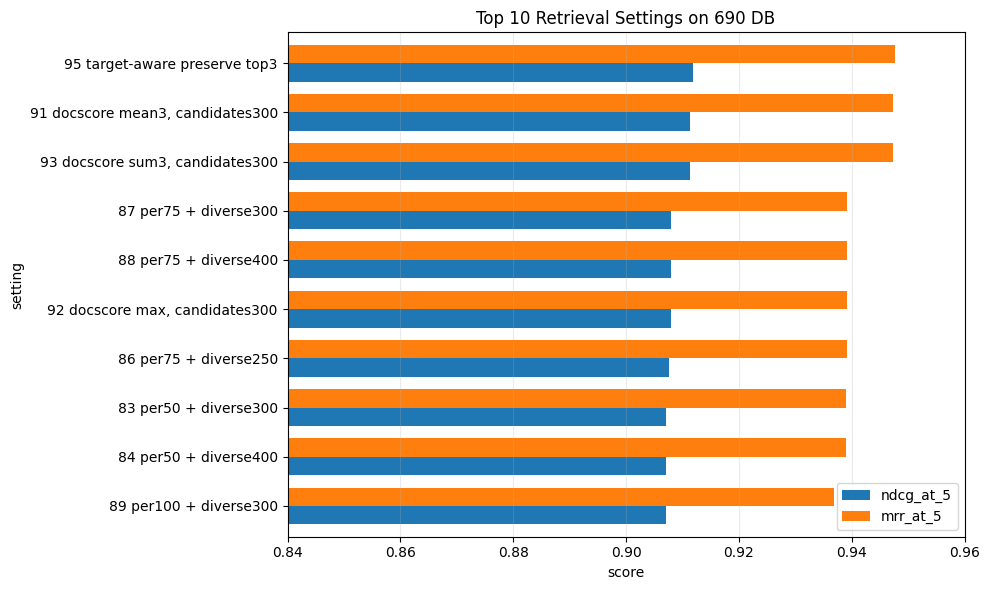

In [58]:
try:
    import matplotlib.pyplot as plt

    plot_df = summary.head(10).set_index('setting')[['ndcg_at_5', 'mrr_at_5']]
    ax = plot_df.iloc[::-1].plot(kind='barh', figsize=(10, 6), width=0.75)
    ax.set_xlim(0.84, 0.96)
    ax.set_title('Top 10 Retrieval Settings on 690 DB')
    ax.set_xlabel('score')
    ax.grid(axis='x', alpha=0.25)
    plt.tight_layout()
    plt.show()
except ModuleNotFoundError:
    print('matplotlib이 설치되어 있지 않습니다. 필요하면 `pip install matplotlib` 후 다시 실행하세요.')


## 5. 해석

- 80번 기준 실험은 이미 꽤 높은 성능이었지만, 690 DB에서는 125 DB보다 문서 수와 유사 문서가 많아서 type B, type E 쪽 점수가 내려갔습니다.
- diversity 후보를 200에서 300 이상으로 늘리면 성능이 조금 좋아졌지만, 300과 400은 거의 같았습니다. 후보 폭은 300 근처에서 충분해 보입니다.
- per-query candidates는 50보다 75가 조금 좋았고, 100은 오히려 MRR이 떨어졌습니다. 후보를 너무 많이 늘리면 노이즈가 같이 들어오는 것으로 보입니다.
- keyword rerank는 690에서도 좋지 않았습니다. 특히 type B의 여러 정답 문서 recall을 크게 떨어뜨렸습니다.
- 가장 좋았던 91번은 document scoring입니다. 한 문서의 여러 chunk 점수를 평균내서 문서 단위로 랭킹한 방식이고, type E nDCG가 크게 개선됐습니다.

현재 최종 선택은 95번으로 보는 것이 좋습니다. 94번처럼 target-aware를 공격적으로 적용하면 성능이 크게 떨어졌고, 95번처럼 기존 top-3를 보존할 때만 소폭 개선됐습니다.

## 6. 최종 세팅 재현 명령어

아래 명령어를 실행하면 현재 최종 후보인 95번 세팅을 다시 생성하고 평가할 수 있습니다.

In [59]:
best_generate_cmd = '''.venv/bin/python scripts/generate_eval_predictions.py \
  --canonical-only \
  --retriever dense \
  --chunks data/processed/chunks_v2_690.jsonl \
  --vector-store chroma \
  --index-dir indexes/chroma_kure_v1_chunks_v2_690 \
  --embedding-preset kure \
  --embedding-provider huggingface \
  --query-decomposition \
  --decomposition-candidates-per-query 75 \
  --decomposition-selection rrf \
  --decomposition-conditional \
  --decomposition-min-subqueries 2 \
  --document-scoring \
  --doc-score-candidates 300 \
  --doc-score-method mean_top_n \
  --doc-score-top-n 3 \
  --doc-score-key doc_id \
  --target-aware \
  --target-candidates 30 \
  --target-quota 1 \
  --target-min-count 2 \
  --target-max-count 3 \
  --target-base-preserve 3 \
  --context-max-chars 1200 \
  --output outputs/predictions/95_dense_qdecomp_rrf_per75_docscore_mean3_targetaware30_preserve3_kure_chroma_690_canonical.jsonl \
  --progress-every 50'''

best_eval_cmd = '''.venv/bin/python eval/scripts/run_evaluation.py \
  --predictions outputs/predictions/95_dense_qdecomp_rrf_per75_docscore_mean3_targetaware30_preserve3_kure_chroma_690_canonical.jsonl \
  --canonical-only \
  --include-analysis-metrics \
  --experiment-name 95_dense_qdecomp_rrf_per75_docscore_mean3_targetaware30_preserve3_kure_chroma_690_canonical'''

print(best_generate_cmd)
print()
print(best_eval_cmd)


.venv/bin/python scripts/generate_eval_predictions.py   --canonical-only   --retriever dense   --chunks data/processed/chunks_v2_690.jsonl   --vector-store chroma   --index-dir indexes/chroma_kure_v1_chunks_v2_690   --embedding-preset kure   --embedding-provider huggingface   --query-decomposition   --decomposition-candidates-per-query 75   --decomposition-selection rrf   --decomposition-conditional   --decomposition-min-subqueries 2   --document-scoring   --doc-score-candidates 300   --doc-score-method mean_top_n   --doc-score-top-n 3   --doc-score-key doc_id   --target-aware   --target-candidates 30   --target-quota 1   --target-min-count 2   --target-max-count 3   --target-base-preserve 3   --context-max-chars 1200   --output outputs/predictions/95_dense_qdecomp_rrf_per75_docscore_mean3_targetaware30_preserve3_kure_chroma_690_canonical.jsonl   --progress-every 50

.venv/bin/python eval/scripts/run_evaluation.py   --predictions outputs/predictions/95_dense_qdecomp_rrf_per75_docscore_

## 7. 추가 실험 후보

지금 단계에서는 retrieval만 더 미세하게 튜닝하는 것보다, generation으로 넘겼을 때 실제 답변 품질을 보는 쪽이 더 중요합니다. 그래도 retrieval에서 더 해본다면 아래 정도가 후보입니다.

- 91번 세팅을 기준으로 `doc-score-candidates`를 200, 400으로 비교
- `doc-score-top-n`을 2, 4로 비교
- type B만 따로 보고 query decomposition subquery 생성 규칙 보완
- 데이터 쪽에서 중복/유사 공고의 canonical doc id 정리


## 8. 91번 실제 검색 결과 확인

점수만 보면 어디가 틀렸는지 감이 잘 안 오기 때문에, 최종 선택한 91번 prediction을 기준으로 정답 문서와 검색 문서를 직접 비교합니다.

아래 표에서는 `ndcg_at_5 < 1`인 문제를 중심으로 봅니다. 완전히 틀린 문제뿐 아니라, 정답 문서는 찾았지만 순서가 낮거나 여러 정답 문서 중 일부가 빠진 문제도 포함됩니다.


In [60]:
import ast
import csv
import json
import math
import re
import sys
import unicodedata
from pathlib import Path

import pandas as pd

EVAL_SRC_DIR = Path('../eval/evaluation/src').resolve()
if str(EVAL_SRC_DIR) not in sys.path:
    sys.path.insert(0, str(EVAL_SRC_DIR))

from rag_eval.normalization import (
    documents_match,
    extract_top_unique_documents,
    normalize_doc_id,
    parse_doc_list,
)
from rag_eval.retrieval_metrics import (
    compute_doc_recall_metrics,
    compute_retrieval_metrics,
    first_relevant_rank,
)

PRED_91_PATH = Path('../outputs/predictions/91_dense_qdecomp_rrf_per75_docscore_mean3_300_kure_chroma_690_canonical.jsonl')
EVAL_DIR = Path('../data/eval')
FAILURE_EXPORT_PATH = Path('../eval/evaluation/outputs/eval/ndcg_failures_91_kure_chroma_690.csv')

def load_eval_questions(eval_dir):
    rows = {}
    for idx in range(1, 26):
        path = eval_dir / f'eval_batch_{idx:02d}.csv'
        with path.open(encoding='utf-8-sig', newline='') as file:
            for row in csv.DictReader(file):
                rows[row['id']] = row
    return rows

def load_predictions(path):
    with path.open(encoding='utf-8') as file:
        return [json.loads(line) for line in file if line.strip()]

def matched_ground_truth_docs(gt_docs, retrieved_docs):
    return [
        gt_doc
        for gt_doc in gt_docs
        if any(documents_match(gt_doc, retrieved_doc) for retrieved_doc in retrieved_docs[:5])
    ]

def missing_ground_truth_docs(gt_docs, retrieved_docs):
    return [
        gt_doc
        for gt_doc in gt_docs
        if not any(documents_match(gt_doc, retrieved_doc) for retrieved_doc in retrieved_docs[:5])
    ]

def non_ground_truth_docs(retrieved_docs, gt_docs):
    return [
        retrieved_doc
        for retrieved_doc in retrieved_docs[:5]
        if not any(documents_match(gt_doc, retrieved_doc) for gt_doc in gt_docs)
    ]

eval_rows = load_eval_questions(EVAL_DIR)
predictions_91 = load_predictions(PRED_91_PATH)

analysis_rows = []
prediction_by_id = {}
for pred in predictions_91:
    qid = pred['id']
    prediction_by_id[qid] = pred
    eval_row = eval_rows.get(qid, {})
    gt_docs = parse_doc_list(eval_row.get('ground_truth_docs'))
    retrieved_docs = extract_top_unique_documents(pred.get('retrieved_contexts'), top_k=5)
    retrieval_metrics = compute_retrieval_metrics(gt_docs, retrieved_docs, top_k=5)
    recall_metrics = compute_doc_recall_metrics(gt_docs, retrieved_docs, top_k=5)
    matched_docs = matched_ground_truth_docs(gt_docs, retrieved_docs)
    missing_docs = missing_ground_truth_docs(gt_docs, retrieved_docs)
    extra_docs = non_ground_truth_docs(retrieved_docs, gt_docs)
    first_rank = first_relevant_rank(gt_docs, retrieved_docs)
    ndcg = retrieval_metrics['ndcg_at_5']
    doc_recall = recall_metrics['doc_recall_at_5']
    if not matched_docs:
        failure_type = '정답 문서 전체 누락'
    elif missing_docs:
        failure_type = '여러 정답 문서 중 일부 누락'
    elif pd.notna(first_rank) and first_rank > 1:
        failure_type = '정답 문서는 있으나 순위가 낮음'
    elif ndcg < 1.0:
        failure_type = '정답 문서 순서/불필요 문서 영향'
    else:
        failure_type = '정상'
    analysis_rows.append({
        'id': qid,
        'type': eval_row.get('type'),
        'difficulty': eval_row.get('difficulty'),
        'question': eval_row.get('question') or pred.get('question'),
        'hit_at_5': retrieval_metrics['hit_at_5'],
        'mrr_at_5': retrieval_metrics['mrr_at_5'],
        'ndcg_at_5': ndcg,
        'doc_recall_at_5': doc_recall,
        'first_relevant_rank': first_rank,
        'matched_doc_count': recall_metrics['matched_doc_count'],
        'ground_truth_doc_count': recall_metrics['ground_truth_doc_count'],
        'failure_type': failure_type,
        'ground_truth_docs': gt_docs,
        'retrieved_docs': retrieved_docs[:5],
        'matched_docs': matched_docs,
        'missing_docs': missing_docs,
        'extra_docs': extra_docs,
    })

retrieval_91_detail = pd.DataFrame(analysis_rows)
failure_91 = retrieval_91_detail[retrieval_91_detail['ndcg_at_5'] < 1.0].copy()
failure_91 = failure_91.sort_values(['ndcg_at_5', 'doc_recall_at_5', 'id']).reset_index(drop=True)

print('total questions:', len(retrieval_91_detail))
print('nDCG < 1 cases:', len(failure_91))
display(failure_91['failure_type'].value_counts().rename_axis('failure_type').reset_index(name='count'))


total questions: 500
nDCG < 1 cases: 141


,failure_type,count
0,여러 정답 문서 중 일부 누락,63
1,정답 문서 순서/불필요 문서 영향,39
2,정답 문서는 있으나 순위가 낮음,38
3,정답 문서 전체 누락,1


## 9. 틀린 문제 위주로 보기

아래 표는 nDCG가 낮은 순서대로 정렬한 결과입니다. `missing_docs`는 정답인데 검색 top-5 문서에 없었던 문서이고, `retrieved_docs`는 실제 검색된 문서입니다.


In [61]:
view_cols = [
    'id', 'type', 'difficulty', 'ndcg_at_5', 'doc_recall_at_5', 'first_relevant_rank',
    'failure_type', 'question', 'ground_truth_docs', 'retrieved_docs', 'missing_docs',
]

failure_view = failure_91[view_cols].copy()
for col in ['ground_truth_docs', 'retrieved_docs', 'missing_docs']:
    failure_view[col] = failure_view[col].apply(lambda docs: '\n'.join(docs))

pd.set_option('display.max_colwidth', 220)
display(failure_view.head(40))

FAILURE_EXPORT_PATH.parent.mkdir(parents=True, exist_ok=True)
failure_view.to_csv(FAILURE_EXPORT_PATH, index=False, encoding='utf-8-sig')
print('saved:', FAILURE_EXPORT_PATH)


,id,type,difficulty,ndcg_at_5,doc_recall_at_5,first_relevant_rank,failure_type,question,ground_truth_docs,retrieved_docs,missing_docs
0,Q468,B,하,0.000000,0.000000,NaN,정답 문서 전체 누락,코이카 주도 우즈벡-키르기즈스탄 스마트 관개망 구축 구역 연합 예산(약 50.31억 원)과 (사)부산국제영화제 예매 행사 시스템망 공급 예산(2.43억 원) 양 과업의 최종 확정 재정금을 하나로 묶어 결산하면 총 얼마인가요?,사단법인아시아물위원회사무국_우즈벡-키르기즈스탄 기후변화대응 스.hwp\n(사)부산국제영화제_2024년 BIFF & ACFM 온라인서비스 재개발 및 행사지원시.hwp,KOICA 전자조달_[긴급] [지문] [국제] 우즈베키스탄 열린 의정활동 상하원 .hwp\nKOICA 전자조달_[지문] [국제] (재공고)우즈베키스탄 ICT기반의 수자원정보.hwp\nKOICA_(재공고) 몽골 철도안전 통합관제시스템 시범사업구축 및 운영지원 .hwp\nKOICA_몽골 철도안전 통합관제시스템 시범사업구축 및 운영지원 수행기관.hwp\nKOICA 전자조달_[지문] [국제]...,사단법인아시아물위원회사무국_우즈벡-키르기즈스탄 기후변화대응 스.hwp\n(사)부산국제영화제_2024년 BIFF & ACFM 온라인서비스 재개발 및 행사지원시.hwp
1,Q260,E,상,0.264068,0.500000,4.0,여러 정답 문서 중 일부 누락,수쨔언꽁샤 씨엠애스 현장 건슐툥합고됴화 사업 쳥 에싼이랑요 그리구 고려댸 포탈시스템 구축 에산이랑 어느게 얼먄큼 더 큰건지 규모 차이 죰 자세히 요략 해쥬쇼!,한국수자원공사_건설통합시스템(CMS) 고도화.hwp\n고려대학교_차세대 포털·학사 정보시스템 구축사업.pdf,한국수출입은행_(긴급) 모잠비크 마푸토 지능형교통시스템(ITS) 구축사업.hwp\nKOICA_가나 북부 2개주 포괄적 일차보건의료체계강화사업 수원국시스템활.hwp\n경상북도 영양군_소규모 공공시설 관리시스템 구축사업.hwp\n한국수자원공사_건설통합시스템(CMS) 고도화.hwp\n해외건설협회_에티오피아 부동산 대량평가 시범시스템 구축 및 전국 확.hwp,고려대학교_차세대 포털·학사 정보시스템 구축사업.pdf
2,Q034,B,상,0.296082,0.333333,2.0,여러 정답 문서 중 일부 누락,"코이카의 '우즈베키스탄 방송시스템 사업', 아시아물위원회의 '우즈벡-키르기즈스탄 관개시스템 사업', 수출입은행의 '모잠비크 ITS 타당성 조사 사업'은 모두 중앙 및 해외 기관 원조 형식으로 수행되는 사업입니다. 이 세 사업의 주 대상국과 핵심 인프라 분야를 정리하고, 해당 예산 규모를 큰 금액부터 내림차순으로 나열하십시오.",KOICA 전자조달_[긴급] [지문] [국제] 우즈베키스탄 열린 의정활동 상하원 .hwp\n사단법인아시아물위원회사무국_우즈벡-키르기즈스탄 기후변화대응 스.hwp\n한국수출입은행_(긴급) 모잠비크 마푸토 지능형교통시스템(ITS) 구축사업.hwp,KOICA 전자조달_[지문] [국제] (재공고)우즈베키스탄 ICT기반의 수자원정보.hwp\nKOICA 전자조달_[긴급] [지문] [국제] 우즈베키스탄 열린 의정활동 상하원 .hwp\nKOICA_몽골 철도안전 통합관제시스템 시범사업구축 및 운영지원 수행기관.hwp\nKOICA_(재공고) 몽골 철도안전 통합관제시스템 시범사업구축 및 운영지원 .hwp\nKOICA 전자조달_[지문] 인도적지...,사단법인아시아물위원회사무국_우즈벡-키르기즈스탄 기후변화대응 스.hwp\n한국수출입은행_(긴급) 모잠비크 마푸토 지능형교통시스템(ITS) 구축사업.hwp
3,Q168,B,하,0.306574,0.500000,3.0,여러 정답 문서 중 일부 누락,(주)에스알의 철도 예약발매 ISMP 사업비용 추산액(0원/미기재)이 경희대학교의 정보시스템 운영 예산(미기재)보다 월등히 높은 규모인가요?,한국철도공사 (용역)_예약발매시스템 개량 ISMP 용역.hwp\n경희대학교_[입찰공고] 산학협력단 정보시스템 운영 용역업체 선정.hwp,경희대학교_[입찰공고] 2024~2025학년도 경희대학교 정보시스템(인포21 등) .hwp\n경희대학교_[재공고] 2024~2025학년도 경희대학교 정보시스템(인포21 등) 운.hwp\n경희대학교_[입찰공고] 산학협력단 정보시스템 운영 용역업체 선정.hwp\n경희대학교_[입찰재공고] 경희대학교 공간관리시스템 구축 용역업체 선.hwp\n경희대학교_[재공고] 산학협력단 정보시스템 운영 용...,한국철도공사 (용역)_예약발매시스템 개량 ISMP 용역.hwp
4,Q391,B,중,0.306574,0.500000,3.0,여러 정답 문서 중 일부 누락,"시립대학교가 학생들을 평가하기 위해 진행하는 종단분석 고도화망과 대비하여, 경희대학교가 산학협력단 내부 결재 관리를 위해 추진하는 정보망에 있어서 시스템이 내장해야 하는 '최종 심의 모듈(결과 산출)'의 본질적인 알고리즘적 성향은 어떻게 분화됩니까?",서울시립대학교_[사전공개] 학업성취도 다차원 종단분석 통합시스템 1차.pdf\n경희대학교_[입찰공고] 산학협력단 정보시스템 운영 용역업체 선정.hwp,경희대학교_[재공고] 2024~2025학년도 경희대학교 정보시스템(인포21 등) 운.hwp\n경희대학교_[재공고] 산학협력단 정보시스템 운영 용역업체 선정.hwp\n경희대학교_[입찰공고] 산학협력단 정보시스템 운영 용역업체 선정.hwp\n경희대학교_[입찰공고] 2024~2025학년도 경희대학교 정보시스템(인포21 등) .hwp\n경희대학교_[입찰재공고] 경희대학교 공간관리시스템 구축 ...,서울시립대학교_[사전공개] 학업성취도 다차원 종단분석 통합시스템 1차.pdf
5,Q253,B,상,0.386853,0.500000,2.0,여러 정답 문서 중 일부 누락,"고려대학교의 메머드급 차세대 포털 사업비용, 수자원공사의 CMS 통합시스템 사업 예산을 더한 합계액을 명기한 후 두 시스템 공히 대규모 발주를 일으킨 핵심 내부 사용자 인터페이스(UI) 병목 현상의 맹점이 각각 교무 행정과 건설 관리라는 도메인에서 어떻게 교착되어왔는지 비평하십시오.",고려대학교_차세대 포털·학사 정보시스템 구축사업.pdf\n한국수자원공사_건설통합시스템(CMS) 고도화.hwp,고려대학교_차세대 포털·학사 정보시스템 구축 사업 재공고.pdf\n고려대학교_차세대 포털·학사 정보시스템 구축사업.pdf\n고려대학교_Student Success Center 시스템 개선 및 교과-비교과 통합관리시스.pdf\n고려대학교_[재공지] 고려대학교 공간관리 통합시스템 구축 사업.hwp\n고려대학교_고려대학교 공간관리 통합시스템 구축 사업.hwp,한국수자원공사_건설통합시스템(CMS) 고도화.hwp
6,Q407,B,하,0.386853,0.500000,2.0,여러 정답 문서 중 일부 누락,사단법인아시아물위원회사무국의 스마트 관개시스템 원조 예산(50.31억)과 서울특별시 여성가족재단의 디지털성범죄 지원센터 시스템 통합 예산(약 3.36억) 두 시스템의 총 사업 자금 차액은 도합 얼마인가요?,"사단법인아시아물위원회사무국_우즈벡-키르기즈스탄 기후변화대응 스.hwp\n서울특별시 여성가족재단_(재공고, 협상) 서울 디지털성범죄 안심지원센.hwp","서울특별시 여성가족재단_(긴급, 협상) 서울 디지털성범죄 안심지원센터.hwp\n서울특별시 여성가족재단_(재공고, 협상) 서울 디지털성범죄 안심지원센.hwp\n서울특별시_수사정보포털시스템 기능고도화 용역.hwp\n서울특별시_AI 교량 영상감시시스템 구축 용역.hwp\n서울특별시_2024년 지도정보 플랫폼 및 전문활용 연계 시스템 고도화 용.pdf",사단법인아시아물위원회사무국_우즈벡-키르기즈스탄 기후변화대응 스.hwp
7,Q410,B,하,0.386853,0.500000,2.0,여러 정답 문서 중 일부 누락,"대검찰청의 사이버범죄 교육시스템 고도화 비용(35,750,000원)과 광주문화재단의 예술통합플랫폼 보수 용역비(61,890,000원) 중 비교적 자본 규모가 열세인 프로젝트는 어디 발주인가요?",대검찰청_아태 사이버범죄 역량강화 허브(APC-HUB) 홈페이지 및 온라인 

saved: ../eval/evaluation/outputs/eval/ndcg_failures_91_kure_chroma_690.csv


## 10. 특정 문제 자세히 보기

`QUESTION_ID`를 바꾸면 해당 문제의 정답 문서, 검색 문서, 각 검색 chunk의 문서명/점수/본문 일부를 확인할 수 있습니다. 실패 표에서 궁금한 `id`를 복사해서 넣으면 됩니다.


In [62]:
QUESTION_ID = failure_91.iloc[0]['id'] if len(failure_91) else 'Q001'

def print_question_detail(question_id):
    row = retrieval_91_detail[retrieval_91_detail['id'] == question_id].iloc[0]
    pred = prediction_by_id[question_id]
    print(f"id: {row['id']} / type: {row['type']} / difficulty: {row['difficulty']}")
    print(f"nDCG@5: {row['ndcg_at_5']:.4f} / doc_recall@5: {row['doc_recall_at_5']:.4f} / failure_type: {row['failure_type']}")
    print('\n[질문]')
    print(row['question'])
    print('\n[정답 문서]')
    for doc in row['ground_truth_docs']:
        marker = 'FOUND' if doc in row['matched_docs'] else 'MISS'
        print(f"- [{marker}] {doc}")
    print('\n[검색 문서 top-5]')
    for idx, doc in enumerate(row['retrieved_docs'], 1):
        marker = 'GT' if doc in set(row['ground_truth_docs']) else '---'
        print(f"{idx}. [{marker}] {doc}")
    print('\n[검색 chunk 상세]')
    for context in pred.get('retrieved_contexts', [])[:5]:
        metadata = context.get('metadata') or {}
        filename = context.get('filename') or metadata.get('source_file')
        score = context.get('score')
        doc_score = context.get('doc_score')
        section = metadata.get('section_path')
        text = str(context.get('text') or '').replace('\n', ' ')
        preview = text[:450] + ('...' if len(text) > 450 else '')
        print(f"\nrank {context.get('rank')} | score={score} | doc_score={doc_score}")
        print(f"문서: {filename}")
        print(f"섹션: {section}")
        print(f"chunk_id: {context.get('chunk_id')}")
        print(f"본문 일부: {preview}")

print_question_detail(QUESTION_ID)


id: Q468 / type: B / difficulty: 하
nDCG@5: 0.0000 / doc_recall@5: 0.0000 / failure_type: 정답 문서 전체 누락

[질문]
코이카 주도 우즈벡-키르기즈스탄 스마트 관개망 구축 구역 연합 예산(약 50.31억 원)과 (사)부산국제영화제 예매 행사 시스템망 공급 예산(2.43억 원) 양 과업의 최종 확정 재정금을 하나로 묶어 결산하면 총 얼마인가요?

[정답 문서]
- [MISS] 사단법인아시아물위원회사무국_우즈벡-키르기즈스탄 기후변화대응 스.hwp
- [MISS] (사)부산국제영화제_2024년 BIFF & ACFM 온라인서비스 재개발 및 행사지원시.hwp

[검색 문서 top-5]
1. [---] KOICA 전자조달_[긴급] [지문] [국제] 우즈베키스탄 열린 의정활동 상하원 .hwp
2. [---] KOICA 전자조달_[지문] [국제] (재공고)우즈베키스탄 ICT기반의 수자원정보.hwp
3. [---] KOICA_(재공고) 몽골 철도안전 통합관제시스템 시범사업구축 및 운영지원 .hwp
4. [---] KOICA_몽골 철도안전 통합관제시스템 시범사업구축 및 운영지원 수행기관.hwp
5. [---] KOICA 전자조달_[지문] [국제] 르완다 통합적 일자리 정보체계 구축사업 시.hwp

[검색 chunk 상세]

rank 1 | score=0.714388681808621 | doc_score=0.714388681808621
문서: KOICA 전자조달_[긴급] [지문] [국제] 우즈베키스탄 열린 의정활동 상하원 .hwp
섹션: 문서 시작
chunk_id: doc_afba17272e87_text_text_0003_part_001_9fa9ea7f65e7
본문 일부: [문서: KOICA 전자조달_[긴급] [지문] [국제] 우즈베키스탄 열린 의정활동 상하원 .hwp | 사업명: [긴급] [지문] [국제] 우즈베키스탄 열린 의정활동 상하원 | 발주기관: KOICA 전자조달 | 섹션: 문서 시작 | 유형: t

## 11. Target-aware 보강 실험 결과

여러 정답 문서 중 일부가 누락되는 문제를 줄이기 위해 target-aware selection을 추가로 실험했습니다.

- 94번: target별 quota를 공격적으로 적용
- 95번: 기존 91번의 top-3는 유지하고, 남은 슬롯만 target-aware로 보강

결과적으로 94번은 성능이 크게 떨어졌고, 95번은 91번보다 소폭 개선됐습니다.


In [63]:
target_compare_names = [
    '91_dense_qdecomp_rrf_per75_docscore_mean3_300_kure_chroma_690_canonical',
    '94_dense_qdecomp_rrf_per75_docscore_mean3_targetaware30_max3_kure_chroma_690_canonical',
    '95_dense_qdecomp_rrf_per75_docscore_mean3_targetaware30_preserve3_kure_chroma_690_canonical',
]
target_compare = summary[summary['experiment_name'].isin(target_compare_names)].copy()
target_compare['setting_order'] = target_compare['experiment_name'].map({name: idx for idx, name in enumerate(target_compare_names)})
target_compare = target_compare.sort_values('setting_order')
target_cols = [
    'setting', 'hit_at_5', 'mrr_at_5', 'ndcg_at_5',
    'type_b_ndcg', 'type_b_doc_recall', 'type_b_multi_doc_recall', 'type_e_ndcg',
]
display(target_compare[target_cols])

base = target_compare[target_compare['experiment_name'] == target_compare_names[0]].iloc[0]
delta = target_compare[target_cols].copy()
for metric in ['hit_at_5', 'mrr_at_5', 'ndcg_at_5', 'type_b_ndcg', 'type_b_doc_recall', 'type_b_multi_doc_recall', 'type_e_ndcg']:
    delta[f'delta_{metric}'] = delta[metric] - base[metric]
display(delta[['setting', 'delta_mrr_at_5', 'delta_ndcg_at_5', 'delta_type_b_ndcg', 'delta_type_b_doc_recall', 'delta_type_b_multi_doc_recall']])


,setting,hit_at_5,mrr_at_5,ndcg_at_5,type_b_ndcg,type_b_doc_recall,type_b_multi_doc_recall,type_e_ndcg
1,"91 docscore mean3, candidates300",0.998,0.947333,0.911264,0.837844,0.851250,0.851250,0.928895
15,94 target-aware aggressive,0.990,0.883700,0.855672,0.747129,0.787917,0.787917,0.896988
0,95 target-aware preserve top3,1.000,0.947733,0.911912,0.839462,0.854583,0.854583,0.928895


,setting,delta_mrr_at_5,delta_ndcg_at_5,delta_type_b_ndcg,delta_type_b_doc_recall,delta_type_b_multi_doc_recall
1,"91 docscore mean3, candidates300",0.000000,0.000000,0.000000,0.000000,0.000000
15,94 target-aware aggressive,-0.063633,-0.055593,-0.090715,-0.063333,-0.063333
0,95 target-aware preserve top3,0.000400,0.000647,0.001618,0.003333,0.003333


/tmp/ipykernel_42419/1256199804.py:11: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_42419/1256199804.py:11: UserWarning: Glyph 54744 (\N{HANGUL SYLLABLE HEOM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_42419/1256199804.py:11: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_42419/1256199804.py:11: UserWarning: Glyph 44368 (\N{HANGUL SYLLABLE GYO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/beomsoo/chatbot/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/beomsoo/chatbot/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 54744 (\N{HANGUL SYLLABLE HEOM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(byt

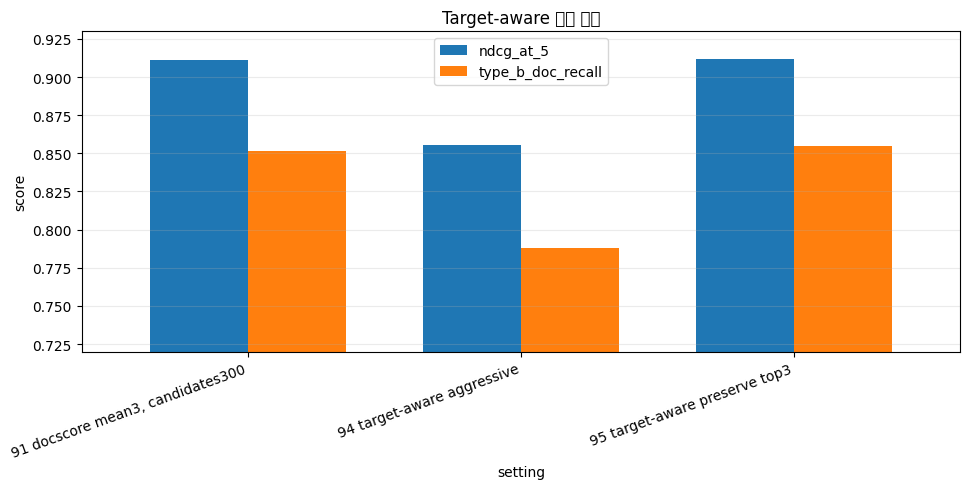

In [64]:
try:
    import matplotlib.pyplot as plt

    plot = target_compare.set_index('setting')[['ndcg_at_5', 'type_b_doc_recall']]
    ax = plot.plot(kind='bar', figsize=(10, 5), width=0.72)
    ax.set_ylim(0.72, 0.93)
    ax.set_title('Target-aware 실험 비교')
    ax.set_ylabel('score')
    ax.grid(axis='y', alpha=0.25)
    plt.xticks(rotation=20, ha='right')
    plt.tight_layout()
    plt.show()
except ModuleNotFoundError:
    print('matplotlib이 설치되어 있지 않습니다.')


## 12. 결론

- target-aware를 무조건 강하게 적용하면 오히려 기존 상위 정답 문서를 밀어내서 성능이 크게 떨어졌습니다.
- 기존 91번의 top-3를 유지하고 남은 자리만 보강하는 95번은 전체 nDCG와 type B doc recall을 소폭 개선했습니다.
- 따라서 generation으로 넘길 retrieval 결과는 95번을 우선 후보로 두는 것이 좋습니다.
- 다만 개선폭은 작기 때문에, 이후에는 retrieval을 계속 미세 조정하기보다 generation에서 `missing_docs 있음/없음`을 기준으로 실패 원인을 분리하는 쪽이 더 효율적입니다.


## 13. 최종 세팅(95번) 틀린 문제 직접 보기

아래 셀은 최종 후보인 95번 prediction을 공식 eval과 같은 문서 매칭 기준으로 다시 계산해서 `nDCG@5 < 1`인 문제만 보여줍니다.

- `failure_type`으로 실패 유형을 먼저 보고
- `missing_docs`로 빠진 정답 문서를 확인하고
- 아래 상세 셀에서 원하는 `question_id`를 넣어 검색 chunk까지 확인하면 됩니다.


In [65]:
import ast
import json
import sys
from pathlib import Path

import pandas as pd


def find_project_root():
    cwd = Path.cwd().resolve()
    for candidate in [cwd, *cwd.parents]:
        if (candidate / 'eval/evaluation/src').exists() and (candidate / 'outputs/predictions').exists():
            return candidate
    raise FileNotFoundError('project root를 찾지 못했습니다. chatbot repo 안에서 노트북을 실행해주세요.')

PROJECT_ROOT = find_project_root()
EVAL_SRC_DIR = PROJECT_ROOT / 'eval/evaluation/src'
if str(EVAL_SRC_DIR) not in sys.path:
    sys.path.insert(0, str(EVAL_SRC_DIR))

from rag_eval.normalization import documents_match

FINAL_PRED_PATH = PROJECT_ROOT / 'outputs/predictions/95_dense_qdecomp_rrf_per75_docscore_mean3_targetaware30_preserve3_kure_chroma_690_canonical.jsonl'
FINAL_EVAL_RESULTS_PATH = PROJECT_ROOT / 'eval/evaluation/outputs/eval/eval_results.csv'
FINAL_FAILURE_EXPORT_PATH = PROJECT_ROOT / 'eval/evaluation/outputs/eval/ndcg_failures_95_kure_chroma_690.csv'


def load_predictions(path):
    with path.open(encoding='utf-8') as file:
        return [json.loads(line) for line in file if line.strip()]


def parse_list_cell(value):
    if pd.isna(value) or value == '':
        return []
    if isinstance(value, list):
        return value
    return ast.literal_eval(value)


def doc_in_list(doc, candidates):
    return any(documents_match(doc, candidate) for candidate in candidates)


def make_failure_type(row):
    if bool(row.get('prediction_missing')):
        return 'prediction 누락'
    if row['matched_doc_count'] == 0:
        return '정답 문서 전체 누락'
    if row['matched_doc_count'] < row['ground_truth_doc_count']:
        return '여러 정답 문서 중 일부 누락'
    if pd.notna(row['first_relevant_rank']) and row['first_relevant_rank'] > 1:
        return '정답 문서는 있으나 순위가 낮음'
    if row['ndcg_at_5'] < 1.0:
        return '정답 문서 순서/불필요 문서 영향'
    return '정상'

predictions_final = load_predictions(FINAL_PRED_PATH)
prediction_by_id_final = {pred['id']: pred for pred in predictions_final}
question_by_id_final = {pred['id']: pred.get('question') for pred in predictions_final}

eval_results_final = pd.read_csv(FINAL_EVAL_RESULTS_PATH, encoding='utf-8-sig')
for col in ['retrieved_doc_ids', 'ground_truth_docs']:
    eval_results_final[col] = eval_results_final[col].apply(parse_list_cell)

eval_results_final['question'] = eval_results_final['id'].map(question_by_id_final)
eval_results_final['failure_type'] = eval_results_final.apply(make_failure_type, axis=1)
eval_results_final['missing_docs'] = eval_results_final.apply(
    lambda row: [doc for doc in row['ground_truth_docs'] if not doc_in_list(doc, row['retrieved_doc_ids'])],
    axis=1,
)
eval_results_final['matched_docs'] = eval_results_final.apply(
    lambda row: [doc for doc in row['ground_truth_docs'] if doc_in_list(doc, row['retrieved_doc_ids'])],
    axis=1,
)

retrieval_final_detail = eval_results_final.copy()
final_failure = retrieval_final_detail[retrieval_final_detail['ndcg_at_5'] < 1.0].copy()
final_failure = final_failure.sort_values(['ndcg_at_5', 'doc_recall_at_5', 'id']).reset_index(drop=True)

print('prediction:', FINAL_PRED_PATH.name)
print('eval results:', FINAL_EVAL_RESULTS_PATH.name)
print('total questions:', len(retrieval_final_detail))
print('nDCG < 1 cases:', len(final_failure))
display(final_failure['failure_type'].value_counts().rename_axis('failure_type').reset_index(name='count'))

view_cols = [
    'id', 'type', 'difficulty', 'ndcg_at_5', 'doc_recall_at_5', 'first_relevant_rank',
    'failure_type', 'question', 'ground_truth_docs', 'retrieved_doc_ids', 'missing_docs',
]
final_failure_view = final_failure[view_cols].copy()
for col in ['ground_truth_docs', 'retrieved_doc_ids', 'missing_docs']:
    final_failure_view[col] = final_failure_view[col].apply(lambda docs: chr(10).join(docs))
final_failure_view = final_failure_view.rename(columns={'retrieved_doc_ids': 'retrieved_docs'})

pd.set_option('display.max_colwidth', 260)
display(final_failure_view.head(50))

FINAL_FAILURE_EXPORT_PATH.parent.mkdir(parents=True, exist_ok=True)
final_failure_view.to_csv(FINAL_FAILURE_EXPORT_PATH, index=False, encoding='utf-8-sig')
print('saved:', FINAL_FAILURE_EXPORT_PATH)


prediction: 95_dense_qdecomp_rrf_per75_docscore_mean3_targetaware30_preserve3_kure_chroma_690_canonical.jsonl
eval results: eval_results.csv
total questions: 500
nDCG < 1 cases: 140


,failure_type,count
0,여러 정답 문서 중 일부 누락,64
1,정답 문서 순서/불필요 문서 영향,39
2,정답 문서는 있으나 순위가 낮음,37


,id,type,difficulty,ndcg_at_5,doc_recall_at_5,first_relevant_rank,failure_type,question,ground_truth_docs,retrieved_docs,missing_docs
0,Q468,B,하,0.237198,0.500000,5.0,여러 정답 문서 중 일부 누락,코이카 주도 우즈벡-키르기즈스탄 스마트 관개망 구축 구역 연합 예산(약 50.31억 원)과 (사)부산국제영화제 예매 행사 시스템망 공급 예산(2.43억 원) 양 과업의 최종 확정 재정금을 하나로 묶어 결산하면 총 얼마인가요?,사단법인아시아물위원회사무국_우즈벡-키르기즈스탄 기후변화대응 스.hwp\n(사)부산국제영화제_2024년 BIFF & ACFM 온라인서비스 재개발 및 행사지원시.hwp,KOICA 전자조달_[긴급] [지문] [국제] 우즈베키스탄 열린 의정활동 상하원 .hwp\nKOICA 전자조달_[지문] [국제] (재공고)우즈베키스탄 ICT기반의 수자원정보.hwp\nKOICA_(재공고) 몽골 철도안전 통합관제시스템 시범사업구축 및 운영지원 .hwp\nKOICA_몽골 철도안전 통합관제시스템 시범사업구축 및 운영지원 수행기관.hwp\n(사)부산국제영화제_2024년 BIFF & ACFM 온라인서비스 재개발 및 행사지원시.hwp,사단법인아시아물위원회사무국_우즈벡-키르기즈스탄 기후변화대응 스.hwp
1,Q260,E,상,0.264068,0.500000,4.0,여러 정답 문서 중 일부 누락,수쨔언꽁샤 씨엠애스 현장 건슐툥합고됴화 사업 쳥 에싼이랑요 그리구 고려댸 포탈시스템 구축 에산이랑 어느게 얼먄큼 더 큰건지 규모 차이 죰 자세히 요략 해쥬쇼!,한국수자원공사_건설통합시스템(CMS) 고도화.hwp\n고려대학교_차세대 포털·학사 정보시스템 구축사업.pdf,한국수출입은행_(긴급) 모잠비크 마푸토 지능형교통시스템(ITS) 구축사업.hwp\nKOICA_가나 북부 2개주 포괄적 일차보건의료체계강화사업 수원국시스템활.hwp\n경상북도 영양군_소규모 공공시설 관리시스템 구축사업.hwp\n한국수자원공사_건설통합시스템(CMS) 고도화.hwp\n해외건설협회_에티오피아 부동산 대량평가 시범시스템 구축 및 전국 확.hwp,고려대학교_차세대 포털·학사 정보시스템 구축사업.pdf
2,Q034,B,상,0.296082,0.333333,2.0,여러 정답 문서 중 일부 누락,"코이카의 '우즈베키스탄 방송시스템 사업', 아시아물위원회의 '우즈벡-키르기즈스탄 관개시스템 사업', 수출입은행의 '모잠비크 ITS 타당성 조사 사업'은 모두 중앙 및 해외 기관 원조 형식으로 수행되는 사업입니다. 이 세 사업의 주 대상국과 핵심 인프라 분야를 정리하고, 해당 예산 규모를 큰 금액부터 내림차순으로 나열하십시오.",KOICA 전자조달_[긴급] [지문] [국제] 우즈베키스탄 열린 의정활동 상하원 .hwp\n사단법인아시아물위원회사무국_우즈벡-키르기즈스탄 기후변화대응 스.hwp\n한국수출입은행_(긴급) 모잠비크 마푸토 지능형교통시스템(ITS) 구축사업.hwp,KOICA 전자조달_[지문] [국제] (재공고)우즈베키스탄 ICT기반의 수자원정보.hwp\nKOICA 전자조달_[긴급] [지문] [국제] 우즈베키스탄 열린 의정활동 상하원 .hwp\nKOICA_몽골 철도안전 통합관제시스템 시범사업구축 및 운영지원 수행기관.hwp\nKOICA 전자조달_[지문] 에콰도르 국가 유전자원 데이터 은행 설립 및 역량.hwp\nKOICA 전자조달_[지문] 인도적지원 정보시스템 기본설계(ISMP) 용역.hwp,사단법인아시아물위원회사무국_우즈벡-키르기즈스탄 기후변화대응 스.hwp\n한국수출입은행_(긴급) 모잠비크 마푸토 지능형교통시스템(ITS) 구축사업.hwp
3,Q168,B,하,0.306574,0.500000,3.0,여러 정답 문서 중 일부 누락,(주)에스알의 철도 예약발매 ISMP 사업비용 추산액(0원/미기재)이 경희대학교의 정보시스템 운영 예산(미기재)보다 월등히 높은 규모인가요?,한국철도공사 (용역)_예약발매시스템 개량 ISMP 용역.hwp\n경희대학교_[입찰공고] 산학협력단 정보시스템 운영 용역업체 선정.hwp,경희대학교_[입찰공고] 2024~2025학년도 경희대학교 정보시스템(인포21 등) .hwp\n경희대학교_[재공고] 2024~2025학년도 경희대학교 정보시스템(인포21 등) 운.hwp\n경희대학교_[입찰공고] 산학협력단 정보시스템 운영 용역업체 선정.hwp\n경희대학교_[입찰재공고] 경희대학교 공간관리시스템 구축 용역업체 선.hwp\n경희대학교_[재공고] 산학협력단 정보시스템 운영 용역업체 선정.hwp,한국철도공사 (용역)_예약발매시스템 개량 ISMP 용역.hwp
4,Q231,B,중,0.306574,0.500000,3.0,여러 정답 문서 중 일부 누락,(사)보험개발원의 실손보험 전산화 체계와 한국생산기술연구원의 2세대 전자조달시스템은 모두 국가 범위의 '인프라 혁신'을 추진합니다. 기존에 각각 어떤 방식의 수기(Manual) 체계를 전자(Digital)로 탈바꿈시키는지 그 대상 매개체를 대조해 보십시오.,사단법인 보험개발원_실손보험 청구 전산화 시스템 구축 사업.hwp\n한국생산기술연구원_2세대 전자조달시스템 기반구축사업.hwp,한국생산기술연구원_2세대 전자조달시스템 구축을 위한 ISMP.hwp\n사단법인 보험개발원_실손보험 청구 전산화 시스템 구축.hwp\n사단법인 보험개발원_실손보험 청구 전산화 시스템 구축 사업.hwp\n한국생산기술연구원_(긴급)2025년 EIP종합정보시스템 유지운영 및 고도화.hwp\n사단법인 보험개발원_보험개발원 학습관리시스템(LMS) 개발.hwp,한국생산기술연구원_2세대 전자조달시스템 기반구축사업.hwp
5,Q391,B,중,0.306574,0.500000,3.0,여러 정답 문서 중 일부 누락,"시립대학교가 학생들을 평가하기 위해 진행하는 종단분석 고도화망과 대비하여, 경희대학교가 산학협력단 내부 결재 관리를 위해 추진하는 정보망에 있어서 시스템이 내장해야 하는 '최종 심의 모듈(결과 산출)'의 본질적인 알고리즘적 성향은 어떻게 분화됩니까?",서울시립대학교_[사전공개] 학업성취도 다차원 종단분석 통합시스템 1차.pdf\n경희대학교_[입찰공고] 산학협력단 정보시스템 운영 용역업체 선정.hwp,경희대학교_[재공고] 2024~2025학년도 경희대학교 정보시스템(인포21 등) 운.hwp\n경희대학교_[재공고] 산학협력단 정보시스템 운영 용역업체 선정.hwp\n경희대학교_[입찰공고] 산학협력단 정보시스템 운영 용역업체 선정.hwp\n경희대학교_[입찰공고] 2024~2025학년도 경희대학교 정보시스템(인포21 등) .hwp\n경희대학교_[입찰재공고] 경희대학교 공간관리시스템 구축 용역업체 선.hwp,서울시립대학교_[사전공개] 학업성취도 다차원 종단분석 통합시스템 1차.pdf
6,Q253,B,상,0.386853,0.500000,2.0,여러 정답 문서 중 일부 누락,"고려대학교의 메머드급 차세대 포털 사업비용, 수자원공사의 CMS 통합시스템 사업 예산을 더한 합계액을 명기한 후 두 시스템 공히 대규모 발주를 일으킨 핵심 내부 사용자 인터페이스(UI) 병목 현상의 맹점이 각각 교무 행정과 건설 관리라는 도메인에서 어떻게 교착되어왔는지 비평하십시오.",고려대학교_차세대 포털·학사 정보시스템 구축사업.pdf\n한국수자원공사_건설통합시스템(CMS) 고도화.hwp,고려대학교_차세대 포털·학사 정보시스템 구축 사업 재공고.pdf\n고려대학교_차세대 포털·학사 정보시스템 구축사업.pdf\n고려대학교_Student Success Center 시스템 개선 및 교과-비교과 통합관리시스.pdf\n고려대학교_[재공지] 고려대학교 공간관리 통합시스템 구축 사업.hwp\n고려대학교_고려대학교 차세대 LMS(학습관리시스템) 구축 사업.pdf,한국수자원공사_건설통합시스템(CMS) 고도화.hwp
7,Q410,B,하,0.386853,0.500000,2.0,여러 정답 문서 중 일부 누락,"대검찰청의 사이버범죄 교육시스템 고도화 비용(35,750,000원)과 광주문화재단의 예술통합플랫폼 보수 용역비(61,890,000원) 중 비교적 자본 규모가 열세인 프로젝트는 어디 발주인가요?",대검찰청_아태 사이

saved: /home/beomsoo/chatbot/eval/evaluation/outputs/eval/ndcg_failures_95_kure_chroma_690.csv


## 14. 특정 실패 문제 상세 확인

`QUESTION_ID_FINAL`에 위 표의 `id`를 넣고 실행하면 정답 문서, 검색된 문서, 실제 검색 chunk 본문 일부를 같이 볼 수 있습니다.


In [66]:
QUESTION_ID_FINAL = final_failure.iloc[0]['id'] if len(final_failure) else 'Q001'


def print_final_question_detail(question_id):
    row = retrieval_final_detail[retrieval_final_detail['id'] == question_id].iloc[0]
    pred = prediction_by_id_final[question_id]
    gt_docs = row['ground_truth_docs']
    retrieved_docs = row['retrieved_doc_ids']

    print(f"id: {row['id']} / type: {row['type']} / difficulty: {row['difficulty']}")
    print(f"nDCG@5: {row['ndcg_at_5']:.4f} / doc_recall@5: {row['doc_recall_at_5']:.4f} / failure_type: {row['failure_type']}")
    print()
    print('[질문]')
    print(row['question'])

    print()
    print('[정답 문서]')
    for doc in gt_docs:
        marker = 'FOUND' if doc_in_list(doc, retrieved_docs) else 'MISS'
        print(f"- [{marker}] {doc}")

    print()
    print('[검색 문서 top-5]')
    for idx, doc in enumerate(retrieved_docs[:5], 1):
        marker = 'GT' if doc_in_list(doc, gt_docs) else '---'
        print(f"{idx}. [{marker}] {doc}")

    print()
    print('[검색 chunk 상세]')
    for context in pred.get('retrieved_contexts', [])[:5]:
        metadata = context.get('metadata') or {}
        filename = context.get('filename') or metadata.get('source_file')
        score = context.get('score')
        doc_score = context.get('doc_score')
        section = metadata.get('section_path')
        text = str(context.get('text') or '').replace(chr(10), ' ')
        preview = text[:550] + ('...' if len(text) > 550 else '')
        print()
        print(f"rank {context.get('rank')} | score={score} | doc_score={doc_score}")
        print(f"문서: {filename}")
        print(f"섹션: {section}")
        print(f"chunk_id: {context.get('chunk_id')}")
        print(f"본문 일부: {preview}")


print_final_question_detail(QUESTION_ID_FINAL)


id: Q468 / type: B / difficulty: 하
nDCG@5: 0.2372 / doc_recall@5: 0.5000 / failure_type: 여러 정답 문서 중 일부 누락

[질문]
코이카 주도 우즈벡-키르기즈스탄 스마트 관개망 구축 구역 연합 예산(약 50.31억 원)과 (사)부산국제영화제 예매 행사 시스템망 공급 예산(2.43억 원) 양 과업의 최종 확정 재정금을 하나로 묶어 결산하면 총 얼마인가요?

[정답 문서]
- [MISS] 사단법인아시아물위원회사무국_우즈벡-키르기즈스탄 기후변화대응 스.hwp
- [FOUND] (사)부산국제영화제_2024년 BIFF & ACFM 온라인서비스 재개발 및 행사지원시.hwp

[검색 문서 top-5]
1. [---] KOICA 전자조달_[긴급] [지문] [국제] 우즈베키스탄 열린 의정활동 상하원 .hwp
2. [---] KOICA 전자조달_[지문] [국제] (재공고)우즈베키스탄 ICT기반의 수자원정보.hwp
3. [---] KOICA_(재공고) 몽골 철도안전 통합관제시스템 시범사업구축 및 운영지원 .hwp
4. [---] KOICA_몽골 철도안전 통합관제시스템 시범사업구축 및 운영지원 수행기관.hwp
5. [GT] (사)부산국제영화제_2024년 BIFF & ACFM 온라인서비스 재개발 및 행사지원시.hwp

[검색 chunk 상세]

rank 1 | score=0.06478893337698202 | doc_score=0.714388681808621
문서: KOICA 전자조달_[긴급] [지문] [국제] 우즈베키스탄 열린 의정활동 상하원 .hwp
섹션: 문서 시작
chunk_id: doc_afba17272e87_text_text_0003_part_001_9fa9ea7f65e7
본문 일부: [문서: KOICA 전자조달_[긴급] [지문] [국제] 우즈베키스탄 열린 의정활동 상하원 .hwp | 사업명: [긴급] [지문] [국제] 우즈베키스탄 열린 의정활동 상하원 | 발주기관: KOICA 전자조달 | 섹션: 문서 

## 15. Cross-encoder rerank 확인 결과

최종 후보인 96번 세팅에 cross-encoder rerank를 붙였을 때 성능이 올라가는지 빠르게 확인했습니다. 전체 500문항을 바로 돌리기에는 모델이 무겁기 때문에, 먼저 canonical eval의 Q001-Q100만 사용해 스크리닝했습니다.

중요한 점은 100문항만 prediction을 만들었기 때문에 `eval_summary.md`의 500문항 평균값으로 비교하면 안 된다는 것입니다. 아래 비교는 `prediction_missing=False`인 같은 100문항만 따로 필터링해서 계산한 값입니다.

| 실험 | hit@5 | MRR@5 | nDCG@5 | multi-doc recall@5 | type B nDCG@5 |
|---|---:|---:|---:|---:|---:|
| 96번 최종 dense 세팅, Q001-Q100 | 0.9750 | 0.9575 | 0.9414 | 0.9375 | 0.8812 |
| 99번 cross-encoder rerank 추가, Q001-Q100 | 0.9650 | 0.8852 | 0.8906 | 0.9125 | 0.8308 |

- cross-encoder 모델: `BAAI/bge-reranker-v2-m3`
- rerank 위치: 최종 후보 구성 이후 `rerank-after-diversity`
- 후보 수: `rerank_candidates=30`
- 비교 파일: `outputs/predictions/99_dense_final_crossencoder_after_limit100_kure_chroma_690_canonical.jsonl`

결론적으로, 현재 파이프라인에 cross-encoder rerank를 단순히 추가하면 성능이 좋아지지 않았습니다. 특히 MRR과 nDCG가 크게 떨어졌고, type B의 다중 문서 질문에서도 손해가 났습니다. 96번 세팅이 이미 문서 단위 커버리지를 잘 맞춰둔 상태라서, cross-encoder가 후보 순서를 다시 섞으면서 일부 정답 문서의 순위가 밀린 것으로 볼 수 있습니다.

따라서 현재 기준 최종 retrieval 세팅은 cross-encoder를 붙이지 않은 96번 조합으로 유지합니다. cross-encoder 모델 캐시는 확인 후 삭제했고, 결과 JSONL 파일만 남겨두었습니다.
